<a href="https://colab.research.google.com/github/krackofficer/EDA-Assignment-in-Machine-Learning-/blob/main/EDA2_Car_Sales_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Upload CSV manually
from google.colab import files
uploaded = files.upload()

Saving Car Sale.csv to Car Sale.csv


In [3]:
import pandas as pd
df = pd.read_csv("Car Sale.csv")
df.head()  # Optional: check data

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÃÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÃÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÃÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

car_df = pd.read_csv('Car Sale.csv')

### 1.What is the average selling price of cars for each dealer, and how does it compare across different dealers?

In [6]:
avg_price_by_dealer = car_df.groupby('Dealer_Name')['Price ($)'].mean().sort_values(ascending=False)
print(avg_price_by_dealer)

Dealer_Name
Rabun Used Car Sales                               29773.808290
Star Enterprises Inc                               29125.608333
U-Haul CO                                          29118.442935
Scrivener Performance Engineering                  29085.855932
Buddy Storbeck's Diesel Service Inc                29068.151832
Iceberg Rentals                                    29027.288889
Ryder Truck Rental and Leasing                     29018.573727
Pars Auto Sales                                    28958.951351
Tri-State Mack Inc                                 28615.276243
Clay Johnson Auto Sales                            28590.631016
Motor Vehicle Branch Office                        28487.128342
Chrysler Plymouth                                  28409.363636
Nebo Chevrolet                                     28389.075269
Diehl Motor CO Inc                                 28225.139785
Gartner Buick Hyundai Saab                         28204.516484
C & M Motors Inc            

### 2.Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends?

In [7]:
price_variation = car_df.groupby('Company')['Price ($)'].std().sort_values(ascending=False)
print(price_variation)

Company
Saab          20921.985148
Lincoln       20346.038326
Plymouth      19640.175925
Cadillac      18726.792645
Nissan        17396.387847
Lexus         17342.503512
Buick         17042.275572
Mercury       16635.381028
Saturn        16225.318168
Ford          15825.554042
Oldsmobile    15524.109925
Toyota        15291.929649
Pontiac       15138.731655
Mercedes-B    15053.802358
BMW           14651.682378
Audi          14080.978938
Volkswagen    13539.990588
Subaru        13374.270854
Volvo         13271.877076
Chevrolet     12844.789823
Infiniti      12592.845344
Mitsubishi    11720.383710
Dodge         11693.743653
Chrysler      11265.154974
Honda         11230.044479
Jaguar        10776.747958
Jeep           9086.530085
Acura          7610.713438
Porsche        5054.695636
Hyundai        3366.342305
Name: Price ($), dtype: float64


### 3.What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare?

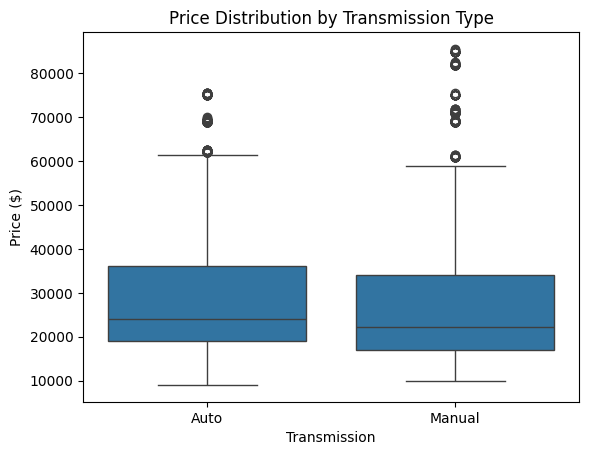

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=car_df, x='Transmission', y='Price ($)')
plt.title('Price Distribution by Transmission Type')
plt.show()

### 4.What is the distribution of car prices across different regions?

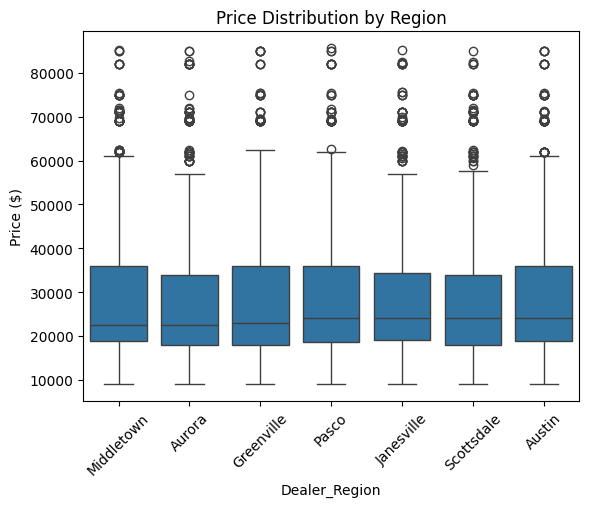

In [9]:
sns.boxplot(data=car_df, x='Dealer_Region', y='Price ($)')
plt.xticks(rotation=45)
plt.title('Price Distribution by Region')
plt.show()

### 5.What is the distribution of cars based on body styles?

Body Style
Hatchback    2023
SUV          1793
Sedan        1353
Passenger    1129
Hardtop       671
Name: count, dtype: int64


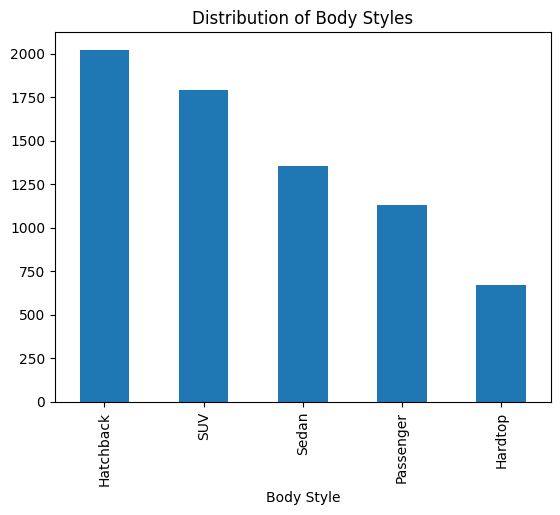

In [10]:
body_style_counts = car_df['Body Style'].value_counts()
print(body_style_counts)
body_style_counts.plot(kind='bar', title='Distribution of Body Styles')
plt.show()

### 6.How does the average selling price of cars vary by customer gender and annual income?

In [11]:
avg_price_gender_income = car_df.groupby(['Gender'])[['Price ($)', 'Annual Income']].mean()
print(avg_price_gender_income)

           Price ($)  Annual Income
Gender                             
Female  28287.116850  820539.114267
Male    28376.402399  868485.778967


### 7.What is the distribution of car prices by region, and how does the number of cars sold vary by region?

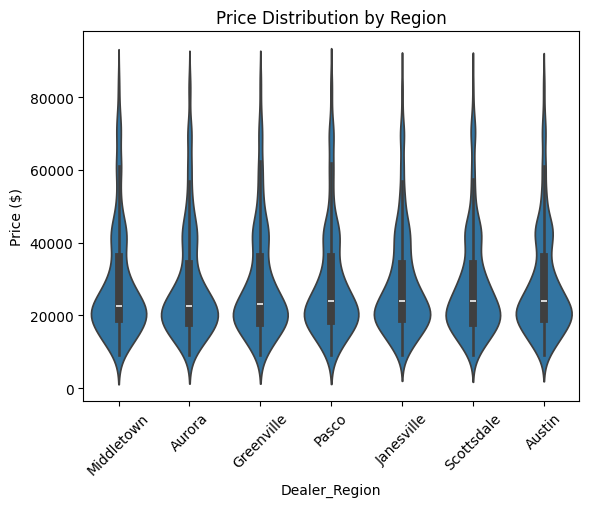

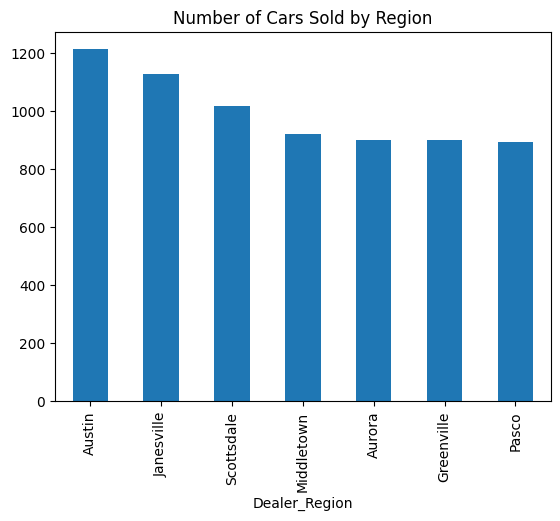

In [12]:
sns.violinplot(data=car_df, x='Dealer_Region', y='Price ($)')
plt.xticks(rotation=45)
plt.title('Price Distribution by Region')
plt.show()

region_counts = car_df['Dealer_Region'].value_counts()
region_counts.plot(kind='bar', title='Number of Cars Sold by Region')
plt.show()

### 8.How does the average car price differ between cars with different engine sizes?

In [13]:
avg_price_by_engine = car_df.groupby('Engine')['Price ($)'].mean().sort_values(ascending=False)
print(avg_price_by_engine)

Engine
DoubleÃÂ Overhead Camshaft    28512.648028
Overhead Camshaft              28179.682277
Name: Price ($), dtype: float64


### 9.How do car prices vary based on the customer’s annual income bracket?

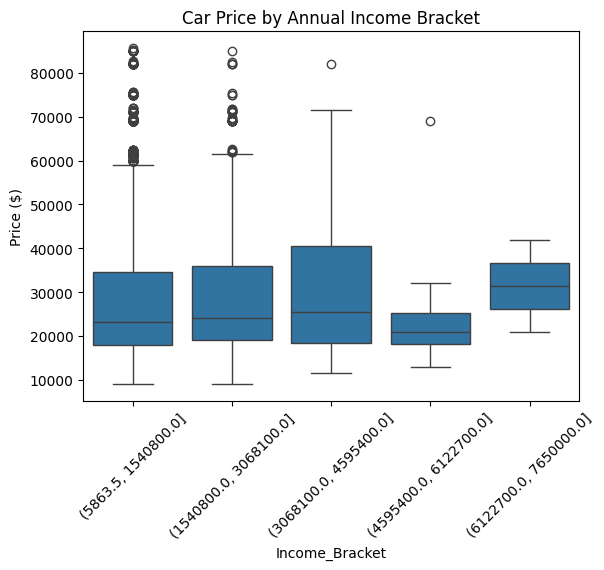

In [14]:
car_df['Income_Bracket'] = pd.cut(car_df['Annual Income'], bins=5)
sns.boxplot(data=car_df, x='Income_Bracket', y='Price ($)')
plt.xticks(rotation=45)
plt.title('Car Price by Annual Income Bracket')
plt.show()

### 10.What are the top 5 car models with the highest number of sales, and how does their price distribution look?

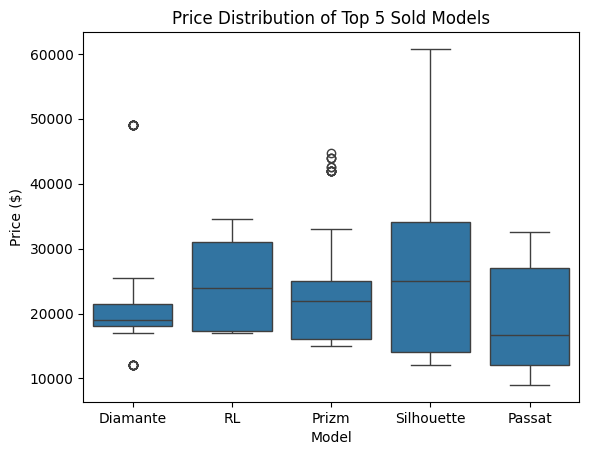

In [15]:
top_models = car_df['Model'].value_counts().head(5).index
sns.boxplot(data=car_df[car_df['Model'].isin(top_models)], x='Model', y='Price ($)')
plt.title('Price Distribution of Top 5 Sold Models')
plt.show()

### 11.How does car price vary with engine size across different car colors, and which colors have the highest price variation?

Color
Red           16532.132537
Black         14866.543272
Pale White    14001.205769
Name: Price ($), dtype: float64


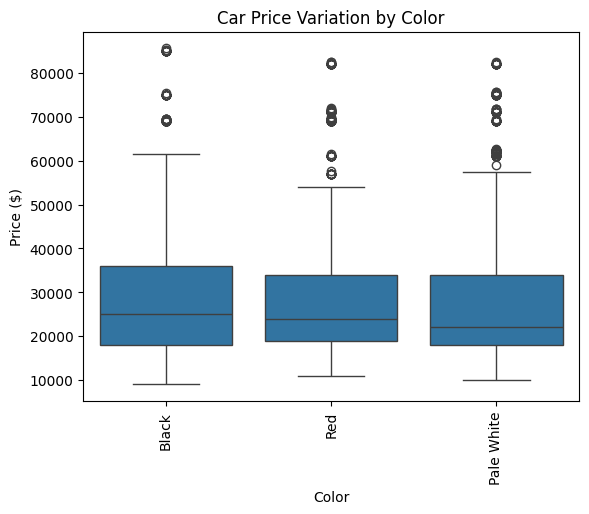

In [16]:
color_price_std = car_df.groupby('Color')['Price ($)'].std().sort_values(ascending=False)
print(color_price_std)

sns.boxplot(data=car_df, x='Color', y='Price ($)')
plt.xticks(rotation=90)
plt.title('Car Price Variation by Color')
plt.show()

### 12.Is there any seasonal trend in car sales based on the date of sale?

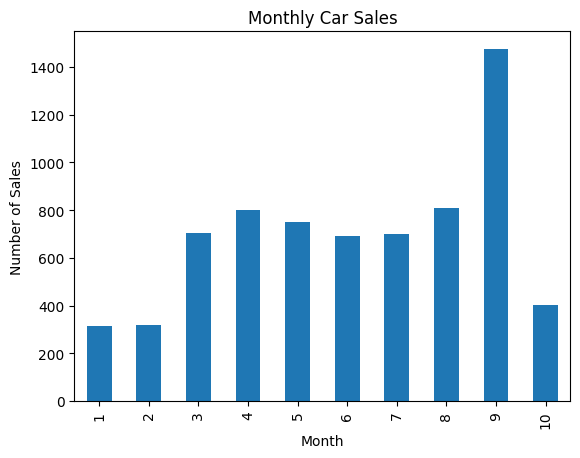

In [17]:
car_df['Date'] = pd.to_datetime(car_df['Date'])
car_df['Month'] = car_df['Date'].dt.month
monthly_sales = car_df['Month'].value_counts().sort_index()
monthly_sales.plot(kind='bar', title='Monthly Car Sales')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.show()

### 13.How does the car price distribution change when considering different combinations of body style and transmission type?

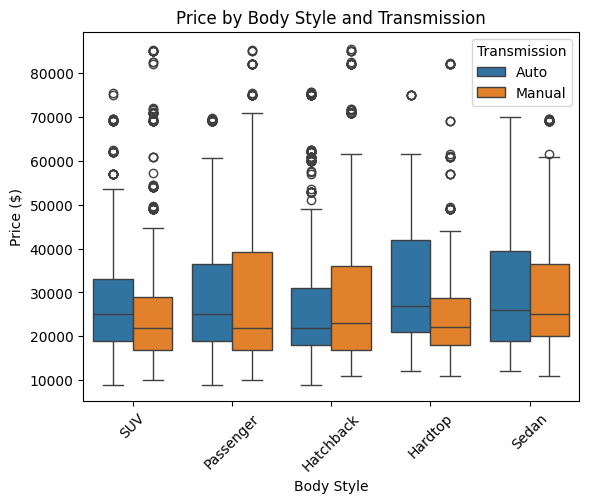

In [18]:
sns.boxplot(data=car_df, x='Body Style', y='Price ($)', hue='Transmission')
plt.xticks(rotation=45)
plt.title('Price by Body Style and Transmission')
plt.show()

### 14.What is the correlation between car price, engine size, and annual income of customers, and how do these features interact?

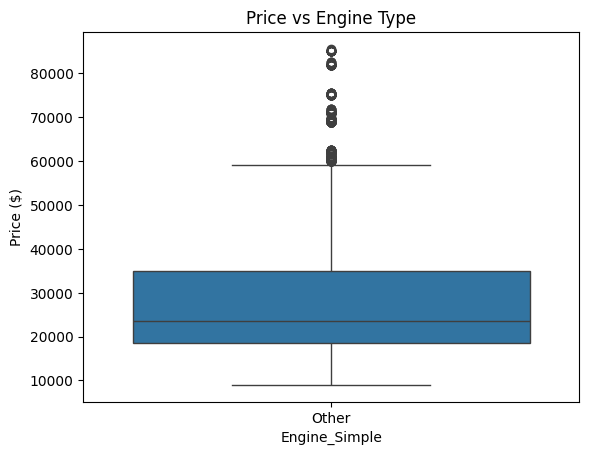

In [19]:
# Convert 'Engine' to simplified format
def simplify_engine(val):
    if 'V6' in val: return 'V6'
    elif 'V8' in val: return 'V8'
    elif 'I4' in val: return 'I4'
    else: return 'Other'

car_df['Engine_Simple'] = car_df['Engine'].apply(simplify_engine)

sns.boxplot(data=car_df, x='Engine_Simple', y='Price ($)')
plt.title('Price vs Engine Type')
plt.show()

### 15.How does the average car price vary across different car models and engine types?

In [20]:
avg_price_model_engine = car_df.groupby(['Model', 'Engine'])['Price ($)'].mean().sort_values(ascending=False).head(10)
print(avg_price_model_engine)

Model    Engine                     
Ranger   DoubleÃÂ Overhead Camshaft    61071.428571
SC       Overhead Camshaft              61069.722222
Sable    Overhead Camshaft              61035.785714
Aurora   Overhead Camshaft              56225.000000
Catera   DoubleÃÂ Overhead Camshaft    55236.576923
DeVille  DoubleÃÂ Overhead Camshaft    54294.789474
LX470    Overhead Camshaft              54055.611111
GS400    Overhead Camshaft              53333.333333
Tacoma   DoubleÃÂ Overhead Camshaft    53065.478261
Prowler  Overhead Camshaft              51588.806452
Name: Price ($), dtype: float64
